In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [ ]:
import os

pwd = os.curdir
save_file = os.path.join(pwd, "Proposition2")
os.makedirs(save_file, exist_ok=True)

### Case 1

In [147]:
#d_0=1+b_0p, d_1=1+b_1p
b_0_true= -0.08
b_1_true= -0.05
c=2

np.random.seed(1)

n_0 = 100
p_0 = np.random.uniform(4, 8, n_0)
d_0 = 1 + b_0_true*p_0 + np.random.normal(0, 0.2, n_0)

n_1 = 300
p_1 = np.random.uniform(4, 10, n_1)
d_1 = 1 + b_1_true*p_1 + np.random.normal(0, 0.2, n_1)


In [148]:
#no fairness
b_hat_0 = np.sum(p_0 * (d_0 - 1)) / np.sum(p_0 ** 2)
b_hat_1 = np.sum(p_1 * (d_1 - 1)) / np.sum(p_1 ** 2)
print(b_hat_0, b_hat_1)

-0.0778794713150937 -0.04897673405078376


In [149]:
def paritywise_price(p_0, p_1, b_hat_0, b_hat_1, alpha):
    def loss(x):
        b_0,b_1 = x
        return np.mean(p_0**2)*(b_0-b_hat_0)**2+np.mean(p_1**2)*(b_1-b_hat_1)**2
    
    def constraint1(x):
        b_0,b_1 = x
        return (1-alpha)*np.abs(1/b_hat_0-1/b_hat_1)-(1/b_0-1/b_1)
    
    def constraint2(x):
        b_0,b_1 = x
        return (1-alpha)*np.abs(1/b_hat_0-1/b_hat_1)-(1/b_1-1/b_0)
    
    constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
    ]
    
    result = minimize(
        fun=loss,
        x0=[b_hat_0, b_hat_1],
        method='SLSQP',
        constraints=constraints,
        options={'disp': True, 'maxiter': 5000}
    )
    
    return result


p0_feo=[]
p1_feo=[]
p0_efo=[]
p1_efo=[]

r1_feo=[]
s1_feo=[]
w1_feo=[]
r1_efo=[]
s1_efo=[]
w1_efo=[]
for alpha in np.linspace(0,1,101):
    result = paritywise_price(p_0, p_1, b_hat_0, b_hat_1, alpha)
    b_0, b_1 = result.x
    price_0, price_1 = -0.5/b_0+c/2, -0.5/b_1+c/2
    p0_feo.append(price_0)
    p1_feo.append(price_1)
    r_0=(price_0-c)*(1+b_0_true*price_0)
    r_1=(price_1-c)*(1+b_1_true*price_1)
    s_0=1/2*(-1/b_0_true-price_0)*(1+b_0_true*price_0)
    s_1=1/2*(-1/b_1_true-price_1)*(1+b_1_true*price_1)
    if price_0>-1/b_0_true:
        r_0=0
        s_0=0
    if price_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r1_feo.append(r)
    s1_feo.append(s)
    w1_feo.append(r+s)


    dp0=b_hat_1/(b_hat_1+b_hat_0)*(-0.5/b_hat_1+0.5/b_hat_0)
    dp1=b_hat_0/(b_hat_1+b_hat_0)*(-0.5/b_hat_0+0.5/b_hat_1)
    
    x_0=-0.5/b_hat_0+alpha*dp0+c/2
    x_1=-0.5/b_hat_1+alpha*dp1+c/2
    if (x_0-c)*(1+b_hat_0*x_0)+(x_1-c)*(1+b_hat_1*x_1)>(-0.5/b_hat_1-c/2)*(1+b_hat_1*(-0.5/b_hat_1+c/2)):
        p0_efo.append(x_0)
        p1_efo.append(x_1)
        r_0=(x_0-c)*(1+b_0_true*x_0)
        r_1=(x_1-c)*(1+b_1_true*x_1)
        s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
        s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
        if x_0>-1/b_0_true:
            r_0=0
            s_0=0
        if x_1>-1/b_1_true:  
            r_1=0
            s_1=0
        r=r_0+r_1
        s=s_0+s_1
        r1_efo.append(r)
        s1_efo.append(s)
        w1_efo.append(r+s)
    else:
        x_0=-0.5/b_hat_1+c/2
        x_1=-0.5/b_hat_1+c/2
        p0_efo.append(x_0)
        p1_efo.append(x_1)
        r_0=(x_0-c)*(1+b_0_true*x_0)
        r_1=(x_1-c)*(1+b_1_true*x_1)
        s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
        s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
        if x_0>-1/b_0_true:
            r_0=0
            s_0=0
        if x_1>-1/b_1_true:  
            r_1=0
            s_1=0
        r=r_0+r_1
        s=s_0+s_1
        r1_efo.append(r)
        s1_efo.append(s)
        w1_efo.append(r+s)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 3
            Gradient evaluations: 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.441445156417975e-06
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5.791817445950143e-06
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.309020391572348e-05
            Iterations: 4
            Function evaluations: 17
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.3375717753445287e-05
            Iterations: 4
            Function evaluations: 17

In [150]:
def paritywise_demand(p_0, p_1, b_hat_0, b_hat_1, alpha):
    def loss(x):
        b_0,b_1 = x
        return np.mean(p_0**2)*(b_0-b_hat_0)**2+np.mean(p_1**2)*(b_1-b_hat_1)**2
    
    def constraint1(x):
        b_0,b_1 = x
        return (1-alpha)*c/2*np.abs(b_hat_0-b_hat_1)-(b_hat_0*(-0.5/b_0+c/2)-b_hat_1*(-0.5/b_1+c/2))
    
    def constraint2(x):
        b_0,b_1 = x
        return (1-alpha)*c/2*np.abs(b_hat_0-b_hat_1)+(b_hat_0*(-0.5/b_0+c/2)-b_hat_1*(-0.5/b_1+c/2))
    
    constraints = [
        {'type': 'ineq', 'fun': constraint1},
        {'type': 'ineq', 'fun': constraint2},
    ]
    
    result = minimize(
        fun=loss,
        x0=[b_hat_0, b_hat_1],
        method='SLSQP',
        constraints=constraints,
        options={'disp': True, 'maxiter': 5000}
    )
    
    return result

d0_feo=[]
d1_feo=[]
d0_efo=[]
d1_efo=[]

r2_feo=[]
s2_feo=[]
w2_feo=[]
r2_efo=[]
s2_efo=[]
w2_efo=[]
for alpha in np.linspace(0,1,101):
    result = paritywise_demand(p_0, p_1, b_hat_0, b_hat_1, alpha)
    b_0, b_1 = result.x
    price_0, price_1 = -0.5/b_0+c/2, -0.5/b_1+c/2
    d0_feo.append(price_0)
    d1_feo.append(price_1)
    
    r_0=(price_0-c)*(1+b_0_true*price_0)
    r_1=(price_1-c)*(1+b_1_true*price_1)
    s_0=1/2*(-1/b_0_true-price_0)*(1+b_0_true*price_0)
    s_1=1/2*(-1/b_1_true-price_1)*(1+b_1_true*price_1)
    if price_0>-1/b_0_true:
        r_0=0
        s_0=0
    if price_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r2_feo.append(r)
    s2_feo.append(s)
    w2_feo.append(r+s)
    
    dp0=c/2*(1/b_hat_0-1/b_hat_1)/(1/b_hat_0+1/b_hat_1)
    dp1=-dp0
    
    x_0=-0.5/b_hat_0+alpha*dp0+c/2
    x_1=-0.5/b_hat_1+alpha*dp1+c/2
    d0_efo.append(x_0)
    d1_efo.append(x_1)
    r_0=(x_0-c)*(1+b_0_true*x_0)
    r_1=(x_1-c)*(1+b_1_true*x_1)
    s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
    s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
    if x_0>-1/b_0_true:
        r_0=0
        s_0=0
    if x_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r2_efo.append(r)
    s2_efo.append(s)
    w2_efo.append(r+s)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 3
            Gradient evaluations: 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.7324870668541486e-08
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.0914936457789455e-07
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.4551098823634227e-07
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 4.364203561880519e-07
            Iterations: 3
            Function evaluations: 

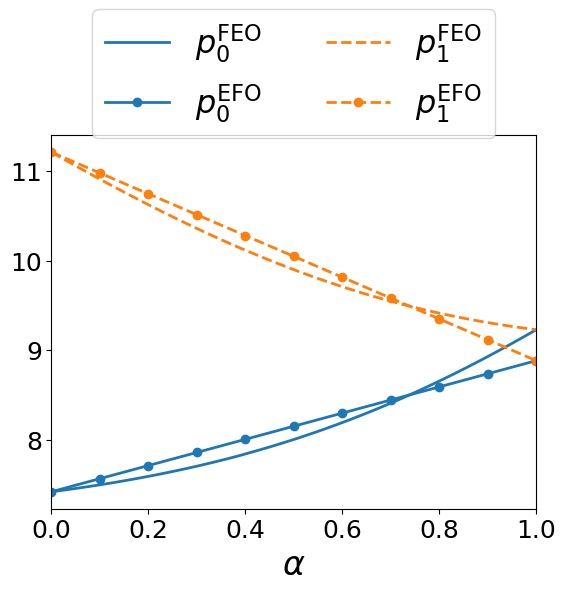

In [151]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, p0_feo, label=r'$p_0^{\mathrm{FEO}}$', linewidth=2, color='tab:blue')
axs.plot(alphas, p0_efo, label=r'$p_0^{\mathrm{EFO}}$', linewidth=2, color='tab:blue',marker='o',markevery=10)
axs.plot(alphas, p1_feo, label=r'$p_1^{\mathrm{FEO}}$', linestyle='--', linewidth=2, color='tab:orange')
axs.plot(alphas, p1_efo, label=r'$p_1^{\mathrm{EFO}}$', linestyle='--', linewidth=2, color='tab:orange',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=2, fontsize=23)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case1a_prices.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

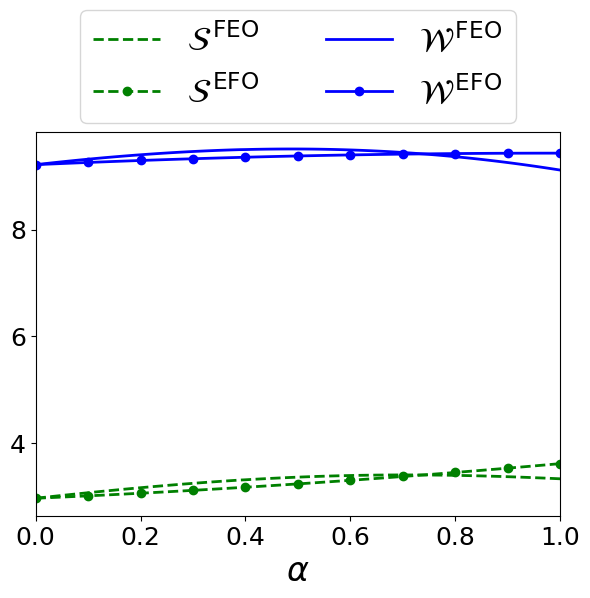

In [152]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, s1_feo, label=r'$\mathcal{S}^{\,\mathrm{FEO}}$', linestyle='--', linewidth=2, color='green')
axs.plot(alphas, s1_efo, label=r'$\mathcal{S}^{\,\mathrm{EFO}}$', linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axs.plot(alphas, w1_feo, label=r'$\mathcal{W}^{\,\mathrm{FEO}}$', linewidth=2, color='blue')
axs.plot(alphas, w1_efo, label=r'$\mathcal{W}^{\,\mathrm{EFO}}$', linewidth=2, color='blue',marker='o',markevery=10)
#axs.plot(alphas, r1_feo, label=r'$\mathcal{R}^{\,\mathrm{FEO}}$', linewidth=2, color='red')
#axs.plot(alphas, r1_efo, label=r'$\mathcal{R}^{\,\mathrm{EFO}}$', linewidth=2, color='red',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.36), ncol=2, fontsize=24)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case1a_outcomes.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

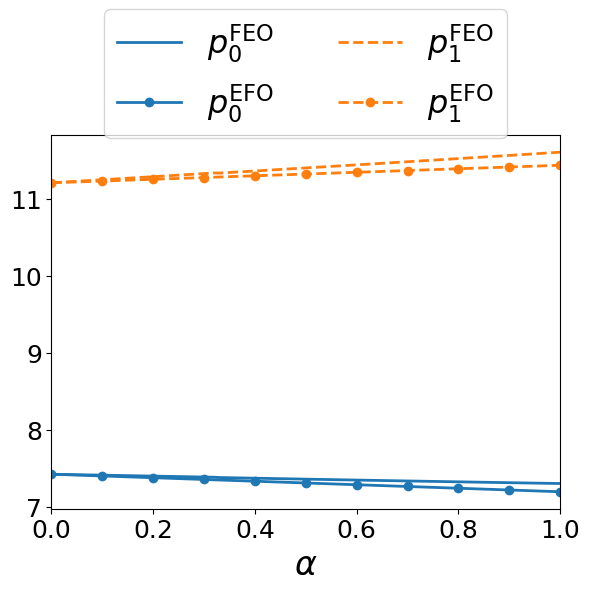

In [153]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, d0_feo, label=r'$p_0^{\mathrm{FEO}}$', linewidth=2, color='tab:blue')
axs.plot(alphas, d0_efo, label=r'$p_0^{\mathrm{EFO}}$', linewidth=2, color='tab:blue',marker='o',markevery=10)
axs.plot(alphas, d1_feo, label=r'$p_1^{\mathrm{FEO}}$', linestyle='--', linewidth=2, color='tab:orange')
axs.plot(alphas, d1_efo, label=r'$p_1^{\mathrm{EFO}}$', linestyle='--', linewidth=2, color='tab:orange',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=2, fontsize=23)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case2a_prices.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15472\2954371828.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


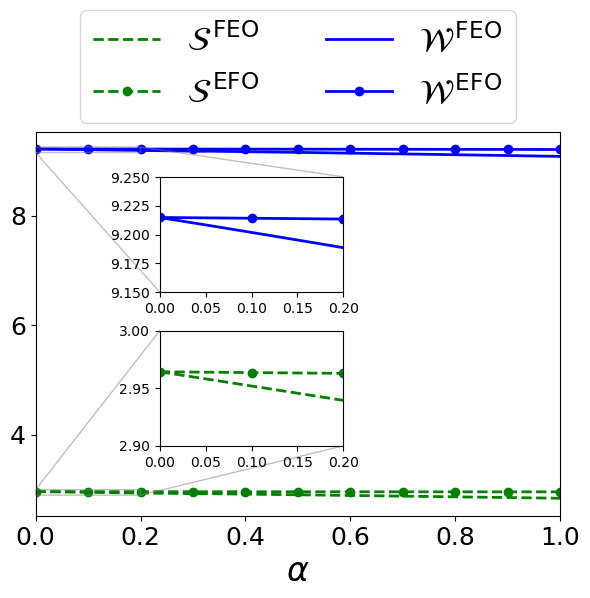

In [154]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, s2_feo, label=r'$\mathcal{S}^{\,\mathrm{FEO}}$', linestyle='--', linewidth=2, color='green')
axs.plot(alphas, s2_efo, label=r'$\mathcal{S}^{\,\mathrm{EFO}}$', linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axs.plot(alphas, w2_feo, label=r'$\mathcal{W}^{\,\mathrm{FEO}}$', linewidth=2, color='blue')
axs.plot(alphas, w2_efo, label=r'$\mathcal{W}^{\,\mathrm{EFO}}$', linewidth=2, color='blue',marker='o',markevery=10)
#axs.plot(alphas, r1_feo, label=r'$\mathcal{R}^{\,\mathrm{FEO}}$', linewidth=2, color='red')
#axs.plot(alphas, r1_efo, label=r'$\mathcal{R}^{\,\mathrm{EFO}}$', linewidth=2, color='red',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.36), ncol=2, fontsize=24)
    axs.set_xlim([min(alphas), max(alphas)])
    
axins = inset_axes(axs, width="35%", height="30%", bbox_to_anchor=(-0.4, -0.5, 1, 1), bbox_transform=axs.transAxes)
axins.plot(alphas, s2_feo, linestyle='--', linewidth=2, color='green')
axins.plot(alphas, s2_efo, linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axins.set_xlim(0.0, 0.2)
axins.set_ylim(2.9, 3.0)
axins.tick_params(axis='both', labelsize=10)
axs.indicate_inset_zoom(axins)

axins2 = inset_axes(axs, width="35%", height="30%", bbox_to_anchor=(-0.4, -0.1, 1, 1), bbox_transform=axs.transAxes)
axins2.plot(alphas, w2_feo, linewidth=2, color='blue')
axins2.plot(alphas, w2_efo, linewidth=2, color='blue',marker='o',markevery=10)
axins2.set_xlim(0.0, 0.2)
axins2.set_ylim(9.15, 9.25)
axins2.tick_params(axis='both', labelsize=10)
axs.indicate_inset_zoom(axins2)

plt.tight_layout()        
result = os.path.join(save_file, f"Case2a_outcomes.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

### Case 2

In [155]:
#d_0=1+b_0p, d_1=1+b_1p
b_0= -0.08
b_1= -0.05
c=2

np.random.seed(1)

n_0 = 100
p_0 = np.random.uniform(2, 3, n_0)
d_0 = 1 + b_0*p_0 + np.random.normal(0, 0.2, n_0)

n_1 = 300
p_1 = np.random.uniform(11, 12, n_1)
d_1 = 1 + b_1*p_1 + np.random.normal(0, 0.2, n_1)

In [156]:
#no fairness
b_hat_0 = np.sum(p_0 * (d_0 - 1)) / np.sum(p_0 ** 2)
b_hat_1 = np.sum(p_1 * (d_1 - 1)) / np.sum(p_1 ** 2)
print(b_hat_0, b_hat_1)

-0.07421726631084516 -0.04919929201436939


In [157]:
p0_feo=[]
p1_feo=[]
p0_efo=[]
p1_efo=[]

r1_feo=[]
s1_feo=[]
w1_feo=[]
r1_efo=[]
s1_efo=[]
w1_efo=[]
for alpha in np.linspace(0,1,101):
    result = paritywise_price(p_0, p_1, b_hat_0, b_hat_1, alpha)
    b_0, b_1 = result.x
    price_0, price_1 = -0.5/b_0+c/2, -0.5/b_1+c/2
    p0_feo.append(price_0)
    p1_feo.append(price_1)
    r_0=(price_0-c)*(1+b_0_true*price_0)
    r_1=(price_1-c)*(1+b_1_true*price_1)
    s_0=1/2*(-1/b_0_true-price_0)*(1+b_0_true*price_0)
    s_1=1/2*(-1/b_1_true-price_1)*(1+b_1_true*price_1)
    if price_0>-1/b_0_true:
        r_0=0
        s_0=0
    if price_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r1_feo.append(r)
    s1_feo.append(s)
    w1_feo.append(r+s)


    dp0=b_hat_1/(b_hat_1+b_hat_0)*(-0.5/b_hat_1+0.5/b_hat_0)
    dp1=b_hat_0/(b_hat_1+b_hat_0)*(-0.5/b_hat_0+0.5/b_hat_1)
    
    x_0=-0.5/b_hat_0+alpha*dp0+c/2
    x_1=-0.5/b_hat_1+alpha*dp1+c/2
    if (x_0-c)*(1+b_hat_0*x_0)+(x_1-c)*(1+b_hat_1*x_1)>(-0.5/b_hat_1-c/2)*(1+b_hat_1*(-0.5/b_hat_1+c/2)):
        p0_efo.append(x_0)
        p1_efo.append(x_1)
        r_0=(x_0-c)*(1+b_0_true*x_0)
        r_1=(x_1-c)*(1+b_1_true*x_1)
        s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
        s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
        if x_0>-1/b_0_true:
            r_0=0
            s_0=0
        if x_1>-1/b_1_true:  
            r_1=0
            s_1=0
        r=r_0+r_1
        s=s_0+s_1
        r1_efo.append(r)
        s1_efo.append(s)
        w1_efo.append(r+s)
    else:
        x_0=-0.5/b_hat_1+c/2
        x_1=-0.5/b_hat_1+c/2
        p0_efo.append(x_0)
        p1_efo.append(x_1)
        r_0=(x_0-c)*(1+b_0_true*x_0)
        r_1=(x_1-c)*(1+b_1_true*x_1)
        s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
        s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
        if x_0>-1/b_0_true:
            r_0=0
            s_0=0
        if x_1>-1/b_1_true:  
            r_1=0
            s_1=0
        r=r_0+r_1
        s=s_0+s_1
        r1_efo.append(r)
        s1_efo.append(s)
        w1_efo.append(r+s)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 3
            Gradient evaluations: 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7.160187285042689e-07
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.8595373758654983e-06
            Iterations: 4
            Function evaluations: 16
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6.423762833679651e-06
            Iterations: 4
            Function evaluations: 16
            Gradient evaluations: 4
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.140191344434824e-05
            Iterations: 4
            Function evaluations: 16

In [158]:
d0_feo=[]
d1_feo=[]
d0_efo=[]
d1_efo=[]

r2_feo=[]
s2_feo=[]
w2_feo=[]
r2_efo=[]
s2_efo=[]
w2_efo=[]
for alpha in np.linspace(0,1,101):
    result = paritywise_demand(p_0, p_1, b_hat_0, b_hat_1, alpha)
    b_0, b_1 = result.x
    price_0, price_1 = -0.5/b_0+c/2, -0.5/b_1+c/2
    d0_feo.append(price_0)
    d1_feo.append(price_1)
    
    r_0=(price_0-c)*(1+b_0_true*price_0)
    r_1=(price_1-c)*(1+b_1_true*price_1)
    s_0=1/2*(-1/b_0_true-price_0)*(1+b_0_true*price_0)
    s_1=1/2*(-1/b_1_true-price_1)*(1+b_1_true*price_1)
    if price_0>-1/b_0_true:
        r_0=0
        s_0=0
    if price_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r2_feo.append(r)
    s2_feo.append(s)
    w2_feo.append(r+s)
    
    dp0=c/2*(1/b_hat_0-1/b_hat_1)/(1/b_hat_0+1/b_hat_1)
    dp1=-dp0
    
    x_0=-0.5/b_hat_0+alpha*dp0+c/2
    x_1=-0.5/b_hat_1+alpha*dp1+c/2
    d0_efo.append(x_0)
    d1_efo.append(x_1)
    r_0=(x_0-c)*(1+b_0_true*x_0)
    r_1=(x_1-c)*(1+b_1_true*x_1)
    s_0=1/2*(-1/b_0_true-x_0)*(1+b_0_true*x_0)
    s_1=1/2*(-1/b_1_true-x_1)*(1+b_1_true*x_1)
    if x_0>-1/b_0_true:
        r_0=0
        s_0=0
    if x_1>-1/b_1_true:  
        r_1=0
        s_1=0
    r=r_0+r_1
    s=s_0+s_1
    r2_efo.append(r)
    s2_efo.append(s)
    w2_efo.append(r+s)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.0
            Iterations: 1
            Function evaluations: 3
            Gradient evaluations: 1
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7.803584044532223e-09
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3.1217663129970354e-08
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7.024725310761217e-08
            Iterations: 3
            Function evaluations: 14
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.2524827671453868e-07
            Iterations: 4
            Function evaluations: 1

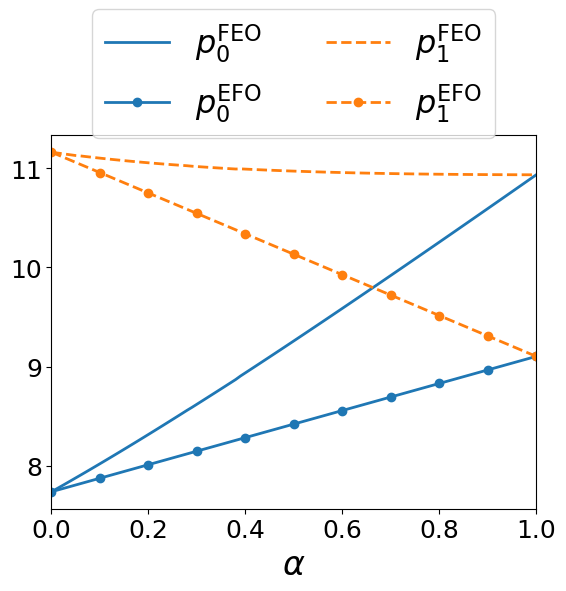

In [159]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, p0_feo, label=r'$p_0^{\mathrm{FEO}}$', linewidth=2, color='tab:blue')
axs.plot(alphas, p0_efo, label=r'$p_0^{\mathrm{EFO}}$', linewidth=2, color='tab:blue',marker='o',markevery=10)
axs.plot(alphas, p1_feo, label=r'$p_1^{\mathrm{FEO}}$', linestyle='--', linewidth=2, color='tab:orange')
axs.plot(alphas, p1_efo, label=r'$p_1^{\mathrm{EFO}}$', linestyle='--', linewidth=2, color='tab:orange',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=2, fontsize=23)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case1b_prices.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

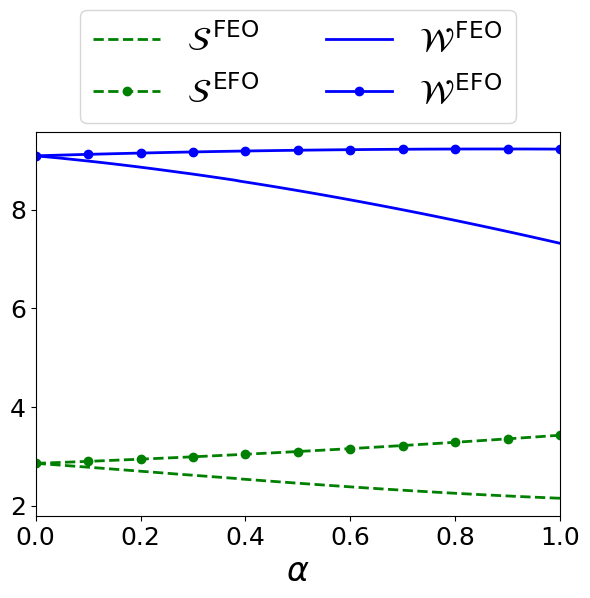

In [160]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, s1_feo, label=r'$\mathcal{S}^{\,\mathrm{FEO}}$', linestyle='--', linewidth=2, color='green')
axs.plot(alphas, s1_efo, label=r'$\mathcal{S}^{\,\mathrm{EFO}}$', linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axs.plot(alphas, w1_feo, label=r'$\mathcal{W}^{\,\mathrm{FEO}}$', linewidth=2, color='blue')
axs.plot(alphas, w1_efo, label=r'$\mathcal{W}^{\,\mathrm{EFO}}$', linewidth=2, color='blue',marker='o',markevery=10)
#axs.plot(alphas, r1_feo, label=r'$\mathcal{R}^{\,\mathrm{FEO}}$', linewidth=2, color='red')
#axs.plot(alphas, r1_efo, label=r'$\mathcal{R}^{\,\mathrm{EFO}}$', linewidth=2, color='red',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.36), ncol=2, fontsize=24)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case1b_outcomes.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

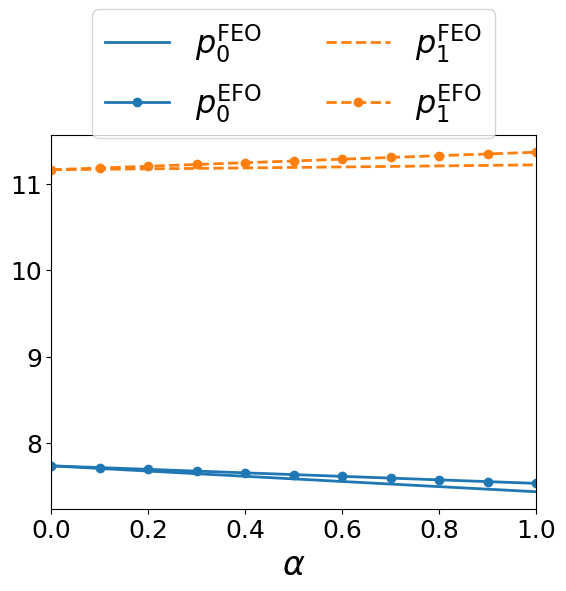

In [161]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, d0_feo, label=r'$p_0^{\mathrm{FEO}}$', linewidth=2, color='tab:blue')
axs.plot(alphas, d0_efo, label=r'$p_0^{\mathrm{EFO}}$', linewidth=2, color='tab:blue',marker='o',markevery=10)
axs.plot(alphas, d1_feo, label=r'$p_1^{\mathrm{FEO}}$', linestyle='--', linewidth=2, color='tab:orange')
axs.plot(alphas, d1_efo, label=r'$p_1^{\mathrm{EFO}}$', linestyle='--', linewidth=2, color='tab:orange',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.38), ncol=2, fontsize=23)
    axs.set_xlim([min(alphas), max(alphas)])

plt.tight_layout()        
result = os.path.join(save_file, f"Case2b_prices.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15472\2488678417.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


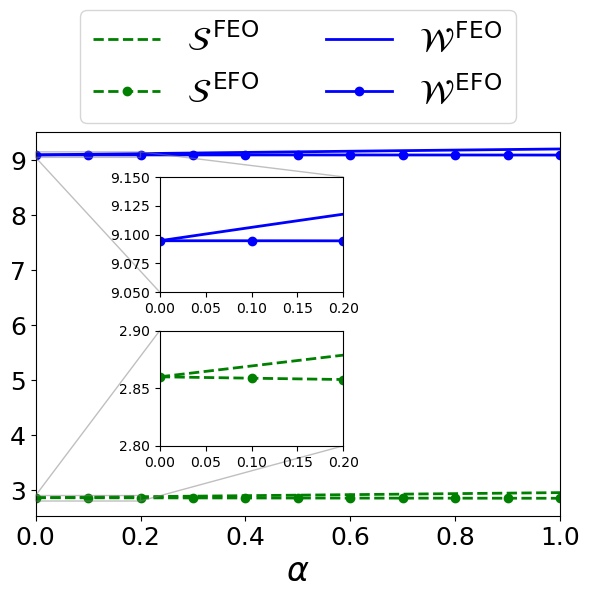

In [162]:
alphas = np.linspace(0, 1, 101)

fig, axs = plt.subplots(figsize=(6,6.5))

axs.plot(alphas, s2_feo, label=r'$\mathcal{S}^{\,\mathrm{FEO}}$', linestyle='--', linewidth=2, color='green')
axs.plot(alphas, s2_efo, label=r'$\mathcal{S}^{\,\mathrm{EFO}}$', linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axs.plot(alphas, w2_feo, label=r'$\mathcal{W}^{\,\mathrm{FEO}}$', linewidth=2, color='blue')
axs.plot(alphas, w2_efo, label=r'$\mathcal{W}^{\,\mathrm{EFO}}$', linewidth=2, color='blue',marker='o',markevery=10)
#axs.plot(alphas, r1_feo, label=r'$\mathcal{R}^{\,\mathrm{FEO}}$', linewidth=2, color='red')
#axs.plot(alphas, r1_efo, label=r'$\mathcal{R}^{\,\mathrm{EFO}}$', linewidth=2, color='red',marker='o',markevery=10)
axs.legend()
axs.tick_params(axis='both', which='major', labelsize=18)

for j in range(1):
    axs.set_xlabel(r'$\alpha$', fontsize=24)
    axs.legend(loc='upper center', bbox_to_anchor=(0.5, 1.36), ncol=2, fontsize=24)
    axs.set_xlim([min(alphas), max(alphas)])
    
axins = inset_axes(axs, width="35%", height="30%", bbox_to_anchor=(-0.4, -0.5, 1, 1), bbox_transform=axs.transAxes)
axins.plot(alphas, s2_feo, linestyle='--', linewidth=2, color='green')
axins.plot(alphas, s2_efo, linestyle='--', linewidth=2, color='green',marker='o',markevery=10)
axins.set_xlim(0.0, 0.2)
axins.set_ylim(2.8, 2.9)
axins.tick_params(axis='both', labelsize=10)
axs.indicate_inset_zoom(axins)

axins2 = inset_axes(axs, width="35%", height="30%", bbox_to_anchor=(-0.4, -0.1, 1, 1), bbox_transform=axs.transAxes)
axins2.plot(alphas, w2_feo, linewidth=2, color='blue')
axins2.plot(alphas, w2_efo, linewidth=2, color='blue',marker='o',markevery=10)
axins2.set_xlim(0.0, 0.2)
axins2.set_ylim(9.05, 9.15)
axins2.tick_params(axis='both', labelsize=10)
axs.indicate_inset_zoom(axins2)

plt.tight_layout()        
result = os.path.join(save_file, f"Case2b_outcomes.pdf")
plt.savefig(result, bbox_inches="tight")
plt.show()